# periscope_drift

using JC's script


In [1]:
source /export/CIAOT/ciaot_install/20180306/ciao-4.10/bin/ciao.bash -o
PFILES="./param;$ASCDS_INSTALL/param:$ASCDS_INSTALL/contrib/param"
mkdir -p ./param
ASCDS_WORK_PATH=./


CIAO configuration is complete... 
CIAO 4.10 Thursday, March  1, 2018
  bindir      : /export/CIAOT/ciaot_install/20180306/ciao-4.10/bin
  CALDB       : 4.7.8


## download

In [5]:
download_chandra_obsid 17128 


  Type     Format      Size  0........H.........1  Download Time Average Rate
  ---------------------------------------------------------------------------
  vv       pdf       196 Kb    already downloaded
  readme   ascii      11 Kb    already downloaded
  oif      fits       25 Kb    already downloaded
  cntr_img jpg       427 Kb    already downloaded
  cntr_img fits      243 Kb    already downloaded
  full_img jpg        46 Kb    already downloaded
  full_img fits       86 Kb    already downloaded
  evt2     fits       40 Mb    already downloaded
  asol     fits       30 Mb    already downloaded
  bpix     fits       57 Kb    already downloaded
  fov      fits        5 Kb    already downloaded
  eph1     fits      311 Kb    already downloaded
  stat     fits        4 Mb    already downloaded
  flt      fits        6 Kb    already downloaded
  msk      fits        5 Kb    already downloaded
  mtl      fits        5 Mb    already downloaded
  evt1     fits      284 Mb    already down

## Run celldetect

In [6]:
celldetect infile= 17128/primary/acisf17128N003_evt2.fits.gz outfile=mysrc.fits clob+


In [7]:
dmsort mysrc.fits"[SRCLIST]" key=-snr outfile=mysrc_snrsort.fits clob+

In [8]:
dmlist mysrc_snrsort.fits"[cols net_counts,x,y,snr,r][net_counts>500][#row=1:5]" data 

 
--------------------------------------------------------------------------------
Data for Table Block SRCLIST
--------------------------------------------------------------------------------
 
ROW    NET_COUNTS           POS(X,Y)                                 SNR                  R[2]
 
     1           4733.68750 (     4064.8904003109,     4071.8738826273)        63.5932884216 [        1.9062685966         1.7274894714]
     2      2102.2819824219 (     4176.2933182333,     6352.5196300491)        22.4180927277 [       94.8498840332        93.4996032715]
     3       703.0838012695 (     4134.0643153527,     2847.7053941909)        19.3047904968 [       29.9088859558        22.9103088379]
     4      1543.6413574219 (     5043.9327146172,     6142.9308584687)        18.1157798767 [       97.5465545654        89.6768798828]
     5      1287.9184570312 (     4283.4835294118,     6332.5188235294)        13.4967308044 [      101.6370544434        87.7643432617]


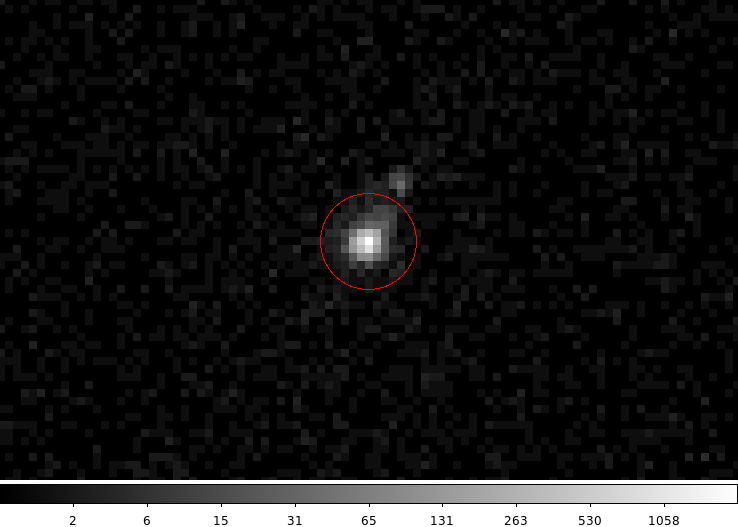

In [9]:
ds9 17128/primary/acisf17128N003_evt2.fits.gz \
 -bin about 4064.8883702839 4071.8739789965 \
 -scale log \
 -regions command "circle 4064.8883702839  4071.8739789965 6 # color=red" \
 -zoom 8 \
 -saveimage png ds9_01.png -quit

display < ds9_01.png

## Run fix script


In [12]:
pset correct_periscope_drift x=4064.8883702839 y=4071.8739789965 radius=6

pset correct_periscope_drift infile= 17128/primary/pcadf557756838N002_asol1.fits.gz
pset correct_periscope_drift evtfile= 17128/primary/acisf17128N003_evt2.fits.gz
pset correct_periscope_drift outfile=driftcorr_asol1.fits
pset correct_periscope_drift corr_plot_root=demo_corr

correct_periscope_drift mode=h

Running: correct_periscope_drift
  version = 0.2
with parameters:
  infile=17128/primary/pcadf557756838N002_asol1.fits.gz
  evtfile=17128/primary/acisf17128N003_evt2.fits.gz
  outfile=driftcorr_asol1.fits
  verbose=2
  and ASCDS_INSTALL is /export/CIAOT/ciaot_install/20180306/ciao-4.10
------------------------------------------------------------
Fitting a line to the data to get reduced stat errors
Fitting a polynomial of degree 2 to the data
Fitting a line to the data to get reduced stat errors
Fitting a polynomial of degree 2 to the data
------------------------------------------------------------
Fit results
	Events show drift range of 0.36 arcsec in yag axis
	Max absolute correction of 0.21 arcsec for yag axis
	Events show drift range of 0.02 arcsec in zag axis
	Max absolute correction of 0.01 arcsec for zag axis
------------------------------------------------------------
Writing out corrected aspect solution file to driftcorr_asol1.fits
	To review fit see correction plots in:
		d

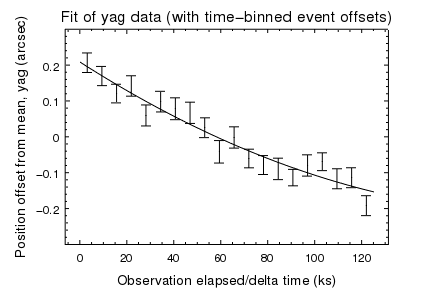

In [13]:
display < demo_corr_fit_yag.png

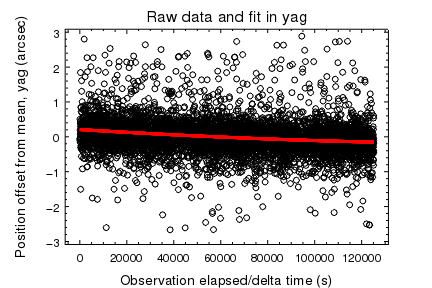

In [14]:
display < demo_corr_data_yag.png

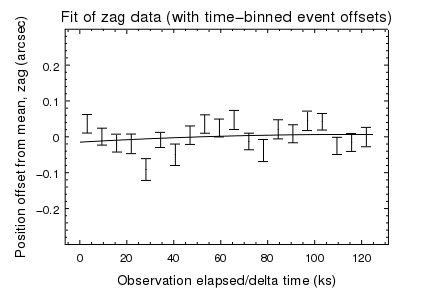

In [15]:
display < demo_corr_fit_zag.png

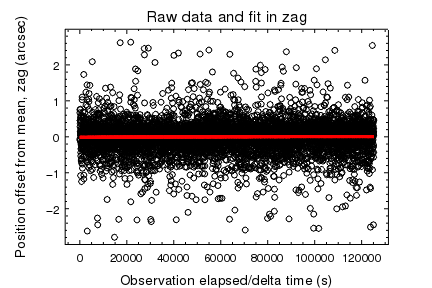

In [16]:
display < demo_corr_data_zag.png

## Apply correction : cuckoo-bird egg

In [17]:
mv -fv 17128/primary/pcadf557756838N002_asol1.fits.gz 17128/pcadf557756838N002_asol1.fits.gz.ORIG
cp -fv driftcorr_asol1.fits 17128/primary/pcadf557756838_driftcorr_asol1.fits

`17128/primary/pcadf557756838N002_asol1.fits.gz' -> `17128/pcadf557756838N002_asol1.fits.gz.ORIG'
`driftcorr_asol1.fits' -> `17128/primary/pcadf557756838_driftcorr_asol1.fits'


In [18]:
chandra_repro indir=17128 check_vf_pha=yes outdir= clob+


Processing input directory '/data/sdsreg/thread_output/CIAO4.10/periscope_drift/17128'

Resetting afterglow status bits in evt1.fits file...

Running the destreak tool on the evt1.fits file...

Running acis_build_badpix and acis_find_afterglow to create a new bad pixel file...

Running acis_process_events to reprocess the evt1.fits file...
Output from acis_process_events:
# acis_process_events (CIAO 4.10): The following error occurred 31 times:
	dsAPEPULSEHEIGHTERR -- WARNING: pulse height is less than split threshold when performing serial CTI adjustment.
Filtering the evt1.fits file by grade and status and time...
Applying the good time intervals from the flt1.fits file...
The new evt2.fits file is: /data/sdsreg/thread_output/CIAO4.10/periscope_drift/17128/repro/acisf17128_repro_evt2.fits

Updating the event file header with chandra_repro HISTORY record
Creating FOV file...
Setting observation-specific bad pixel file in local ardlib.par.

Cleaning up intermediate files

         /da

## Repeat correction

In [19]:
pset correct_periscope_drift evtfile=17128/repro/acisf17128_repro_evt2.fits
pset correct_periscope_drift infile=17128/primary/pcadf557756838_driftcorr_asol1.fits
pset correct_periscope_drift outfile=already_fixed.fits
pset correct_periscope_drift corr_plot_root="already_fixed"

correct_periscope_drift mode=h


Running: correct_periscope_drift
  version = 0.2
with parameters:
  infile=17128/primary/pcadf557756838_driftcorr_asol1.fits
  evtfile=17128/repro/acisf17128_repro_evt2.fits
  outfile=already_fixed.fits
  verbose=2
  and ASCDS_INSTALL is /export/CIAOT/ciaot_install/20180306/ciao-4.10
------------------------------------------------------------
Fitting a line to the data to get reduced stat errors
Fitting a polynomial of degree 2 to the data
Fitting a line to the data to get reduced stat errors
Fitting a polynomial of degree 2 to the data
------------------------------------------------------------
Fit results
	Events show drift range of 0.01 arcsec in yag axis
	Max absolute correction of 0.00 arcsec for yag axis
	Events show drift range of 0.01 arcsec in zag axis
	Max absolute correction of 0.00 arcsec for zag axis
------------------------------------------------------------
Writing out corrected aspect solution file to already_fixed.fits
	To review fit see correction plots in:
		alrea

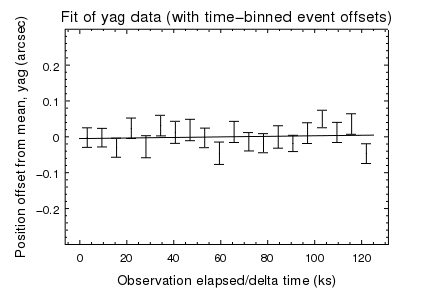

In [21]:
display < already_fixed_fit_yag.png

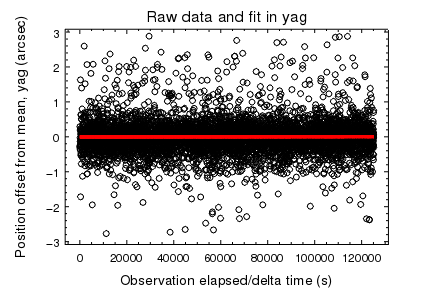

In [22]:
display < already_fixed_data_yag.png

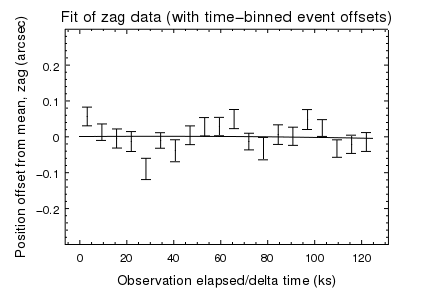

In [23]:
display < already_fixed_fit_zag.png

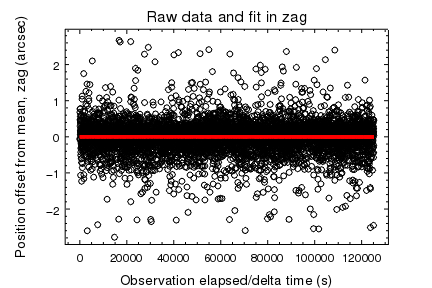

In [24]:
display < already_fixed_data_zag.png

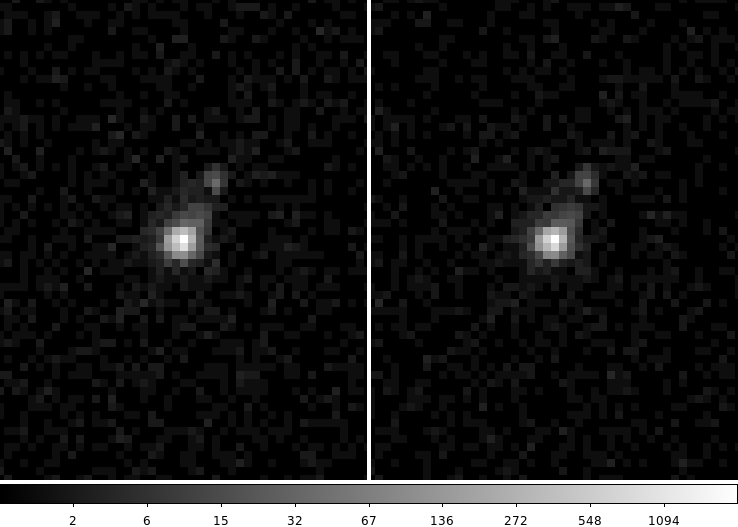

In [25]:
ds9 17128/primary/acisf17128N003_evt2.fits.gz  -scale log -zoom 8 -pan to 4064.8883702839 4071.8739789965 physical \
    17128/repro/acisf17128_repro_evt2.fits -scale log -pan to 4064.8883702839 4071.8739789965 physical \
    -saveimage png ds9_02.png -quit

display < ds9_02.png

In [31]:
dmstat 17128/primary/acisf17128N003_evt2.fits.gz"[sky=circle(4064.8883702839,4071.8739789965,6)][energy=500:7000][cols sky]" cen+ sig+ med-
dmstat 17128/repro/acisf17128_repro_evt2.fits"[sky=circle(4064.8883702839,4071.8739789965,6)][energy=500:7000][cols sky]" cen+ sig+ med-


sky(x, y)[pixel]
    min:	( 4059.1242676 4066.2668457 )	      @:	( 715 2511 )
    max:	( 4070.3671875 4077.7438965 )	      @:	( 1057 4472 )
   mean:	( 4064.8220547 4071.8526857 )
  sigma:	( 0.92167263267 0.96615165671 )
    sum:	( 24254793.2 24296744.976 )
   good:	( 5967 5967 )
   null:	( 0 0 )

sky(x, y)[pixel]
    min:	( 4059.0693359 4066.2390137 )	      @:	( 685 2420 )
    max:	( 4070.6791992 4077.7478027 )	      @:	( 786 5225 )
   mean:	( 4064.820217 4071.8529543 )
  sigma:	( 0.91571362072 0.93157809024 )
    sum:	( 23340197.686 23380579.664 )
   good:	( 5742 5742 )
   null:	( 0 0 )



In [32]:
dmstat 17128/primary/acisf17128N003_evt2.fits.gz"[sky=circle(4064.8883702839,4071.8739789965,6)][energy=500:7000][bin sky=0.1]" cen+ sig+ med-
dmstat 17128/repro/acisf17128_repro_evt2.fits"[sky=circle(4064.8883702839,4071.8739789965,6)][energy=500:7000][bin sky=0.1]" cen+ sig+ med-


EVENTS_IMAGE(x, y)
    min:	0 	      @:	( 4064.1383703 4065.923979 )
    max:	42 	      @:	( 4065.0383703 4071.523979 )
cntrd[log] :	( 59.837271661 60.284062343 )
cntrd[phys]:	( 4064.8220974 4071.8523852 )
sigma_cntrd:	( 43.608644286 43.979842471 )
   good:	11304 
   null:	3096 
EVENTS_IMAGE(x, y)
    min:	0 	      @:	( 4064.1383703 4065.923979 )
    max:	49 	      @:	( 4065.1383703 4071.823979 )
cntrd[log] :	( 59.822013236 60.287704633 )
cntrd[phys]:	( 4064.8205716 4071.8527495 )
sigma_cntrd:	( 42.775593551 43.120828042 )
   good:	11304 
   null:	3096 
